In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load data 
with open('../data/raw/ispu_jakarta_2023.xls', 'r', encoding='utf-8') as f:
    content = f.read()

df = pd.read_html(StringIO(content))[0]

print(f"Data berhasil dimuat!")
print(f"  Jumlah baris  : {df.shape[0]:,}")
print(f"  Jumlah kolom  : {df.shape[1]}")
print(f"  Rentang waktu : {df['tanggal'].min()} s/d {df['tanggal'].max()}")

Data berhasil dimuat!
  Jumlah baris  : 1,825
  Jumlah kolom  : 12
  Rentang waktu : 2022-12-01 s/d 2023-11-30


In [5]:
# Lihat 5 baris pertama
df.head()

,periode_data,tanggal,stasiun,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,parameter_pencemar_kritis,kategori
0,202302,2023-02-25,DKI5 KEBON JERUK JAKARTA BARAT,35,-,13,12,31,18,35,PM10,BAIK
1,202302,2023-02-26,DKI5 KEBON JERUK JAKARTA BARAT,23,-,14,9,32,11,32,O3,BAIK
2,202302,2023-02-27,DKI5 KEBON JERUK JAKARTA BARAT,20,-,13,8,33,13,33,O3,BAIK
3,202302,2023-02-28,DKI5 KEBON JERUK JAKARTA BARAT,30,-,21,11,28,18,30,PM10,BAIK
4,202303,2023-03-01,DKI1 BUNDERAN HI,38,44,50,8,19,27,50,3,BAIK


In [6]:
print("INFO DATASET")
print(f"Baris : {df.shape[0]:,}")
print(f"Kolom : {df.shape[1]}")
print()
print("TIPE DATA")
print(df.dtypes)
print()
print("NILAI UNIK STASIUN")
for s in df['stasiun'].unique():
    print(f"  - {s}")
print()
print("KATEGORI UDARA")
print(df['kategori'].value_counts())

INFO DATASET
Baris : 1,825
Kolom : 12

TIPE DATA
periode_data                  int64
tanggal                      object
stasiun                      object
pm_sepuluh                   object
pm_duakomalima               object
sulfur_dioksida              object
karbon_monoksida             object
ozon                         object
nitrogen_dioksida            object
max                          object
parameter_pencemar_kritis    object
kategori                     object
dtype: object

NILAI UNIK STASIUN
  - DKI5 KEBON JERUK JAKARTA BARAT
  - DKI1 BUNDERAN HI
  - DKI2 KELAPA GADING
  - DKI3 JAGAKARSA
  - DKI4 LUBANG BUAYA
  - DKI5 KEBON JERUK

KATEGORI UDARA
kategori
SEDANG                1358
BAIK                   236
TIDAK SEHAT            207
TIDAK ADA DATA          21
SANGAT TIDAK SEHAT       3
Name: count, dtype: int64


In [10]:
#PEMBERSIHAN DATA

# 1. Salin dataframe supaya data asli tetap aman
df_clean = df.copy()

# 2. Konversi tanggal
df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'])

# 3. Seragamkan nama stasiun DKI5 yang duplikat
# str.split().str.join() membersihkan semua spasi berlebih di tengah sekaligus
df_clean['stasiun'] = df_clean['stasiun'].str.split().str.join(' ')
df_clean['stasiun'] = df_clean['stasiun'].replace({
    'DKI5 KEBON JERUK JAKARTA BARAT': 'DKI5 KEBON JERUK',
})

# 4. Ganti nilai tidak valid jadi NaN (Not a Number = data kosong)
nilai_tidak_valid = ['-', '---', 'TIDAK ADA DATA', 'None']
kolom_polutan = ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida',
                 'karbon_monoksida', 'ozon', 'nitrogen_dioksida', 'max']

for kolom in kolom_polutan:
    df_clean[kolom] = df_clean[kolom].replace(nilai_tidak_valid, np.nan)
    df_clean[kolom] = pd.to_numeric(df_clean[kolom], errors='coerce')

# 5. Hapus baris yang tidak ada data sama sekali
df_clean = df_clean[df_clean['kategori'] != 'TIDAK ADA DATA']

# 6. Tambah kolom bulan untuk analisis tren
df_clean['bulan'] = df_clean['tanggal'].dt.month
df_clean['nama_bulan'] = df_clean['tanggal'].dt.strftime('%b')

#LAPORAN HASIL PEMBERSIHAN
print("HASIL PEMBERSIHAN DATA")
print(f"Baris sebelum : 1,825")
print(f"Baris sesudah : {len(df_clean):,}")
print(f"Baris dibuang : {1825 - len(df_clean)} (kategori 'TIDAK ADA DATA')")
print()
print("CEK TIPE DATA SETELAH DIBERSIHKAN")
print(df_clean[kolom_polutan].dtypes)
print()
print("JUMLAH DATA KOSONG PER KOLOM")
print(df_clean[kolom_polutan].isna().sum())
print()
print("STASIUN SETELAH DISERAGAMKAN")
for s in df_clean['stasiun'].unique():
    print(f"  - {s}")

HASIL PEMBERSIHAN DATA
Baris sebelum : 1,825
Baris sesudah : 1,804
Baris dibuang : 21 (kategori 'TIDAK ADA DATA')

CEK TIPE DATA SETELAH DIBERSIHKAN
pm_sepuluh           float64
pm_duakomalima       float64
sulfur_dioksida      float64
karbon_monoksida     float64
ozon                 float64
nitrogen_dioksida    float64
max                  float64
dtype: object

JUMLAH DATA KOSONG PER KOLOM
pm_sepuluh           201
pm_duakomalima       274
sulfur_dioksida       18
karbon_monoksida      23
ozon                   8
nitrogen_dioksida     45
max                    0
dtype: int64

STASIUN SETELAH DISERAGAMKAN
  - DKI5 KEBON JERUK
  - DKI1 BUNDERAN HI
  - DKI2 KELAPA GADING
  - DKI3 JAGAKARSA
  - DKI4 LUBANG BUAYA


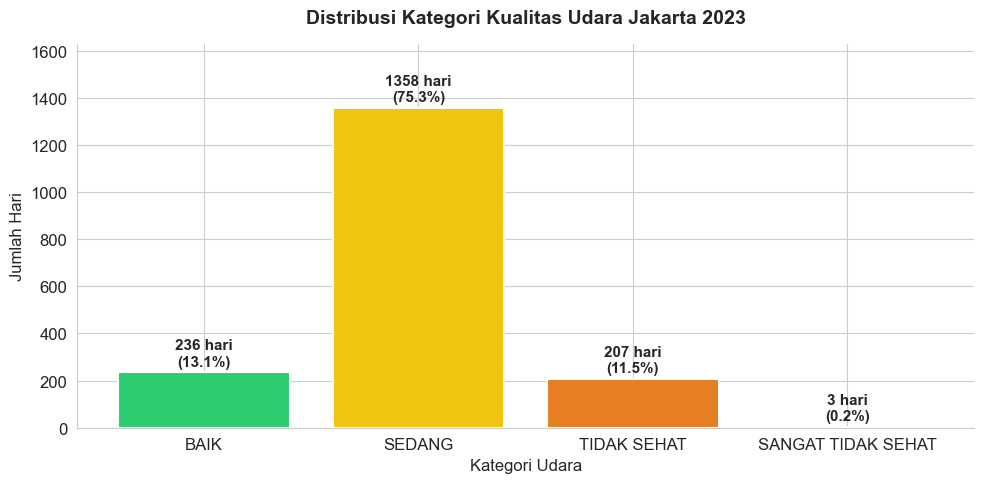

Grafik berhasil disimpan!


In [11]:
#VISUALISASI 1: DISTRIBUSI KATEGORI UDARA

# Urutan kategori dari terbaik ke terburuk
urutan = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT']
warna  = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

# Hitung jumlah per kategori
kategori_count = df_clean['kategori'].value_counts().reindex(urutan)
persen = (kategori_count / kategori_count.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(urutan, kategori_count.values, color=warna, edgecolor='white', linewidth=1.5)

# Tambah label angka dan persen di atas setiap bar
for bar, pct in zip(bars, persen):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 15,
            f'{int(bar.get_height())} hari\n({pct}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribusi Kategori Kualitas Udara Jakarta 2023', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kategori Udara', fontsize=12)
ax.set_ylabel('Jumlah Hari', fontsize=12)
ax.set_ylim(0, kategori_count.max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/viz1_kategori_udara.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik berhasil disimpan!")

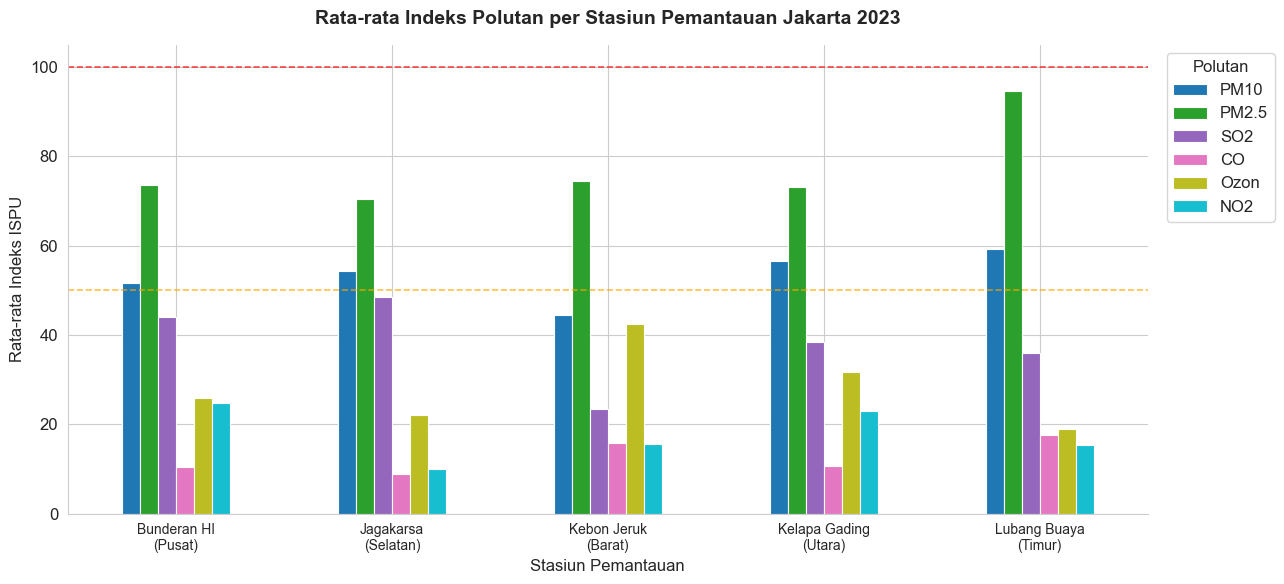

Grafik berhasil disimpan!


In [13]:
#VISUALISASI 2: RATA-RATA ISPU PER STASIUN

kolom_polutan_viz = ['pm_sepuluh', 'pm_duakomalima', 'sulfur_dioksida',
                     'karbon_monoksida', 'ozon', 'nitrogen_dioksida']

label_polutan = ['PM10', 'PM2.5', 'SO2', 'CO', 'Ozon', 'NO2']

# Nama stasiun dipersingkat untuk tampilan grafik
singkat = {
    'DKI1 BUNDERAN HI'   : 'Bunderan HI\n(Pusat)',
    'DKI2 KELAPA GADING' : 'Kelapa Gading\n(Utara)',
    'DKI3 JAGAKARSA'     : 'Jagakarsa\n(Selatan)',
    'DKI4 LUBANG BUAYA'  : 'Lubang Buaya\n(Timur)',
    'DKI5 KEBON JERUK'   : 'Kebon Jeruk\n(Barat)',
}

df_clean['stasiun_singkat'] = df_clean['stasiun'].map(singkat)

# Hitung rata-rata per stasiun
rata_stasiun = df_clean.groupby('stasiun_singkat')[kolom_polutan_viz].mean().round(1)
rata_stasiun.columns = label_polutan

fig, ax = plt.subplots(figsize=(13, 6))

rata_stasiun.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white', linewidth=0.8)

ax.set_title('Rata-rata Indeks Polutan per Stasiun Pemantauan Jakarta 2023',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Stasiun Pemantauan', fontsize=12)
ax.set_ylabel('Rata-rata Indeks ISPU', fontsize=12)
ax.set_xticklabels(rata_stasiun.index, rotation=0, fontsize=10)
ax.legend(title='Polutan', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

# Garis referensi batas SEDANG (50) dan TIDAK SEHAT (100)
ax.axhline(y=50, color='orange', linestyle='--', linewidth=1.2, alpha=0.7, label='Batas Sedang (50)')
ax.axhline(y=100, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Batas Tidak Sehat (100)')

plt.tight_layout()
plt.savefig('../data/viz2_polutan_per_stasiun.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik berhasil disimpan!")

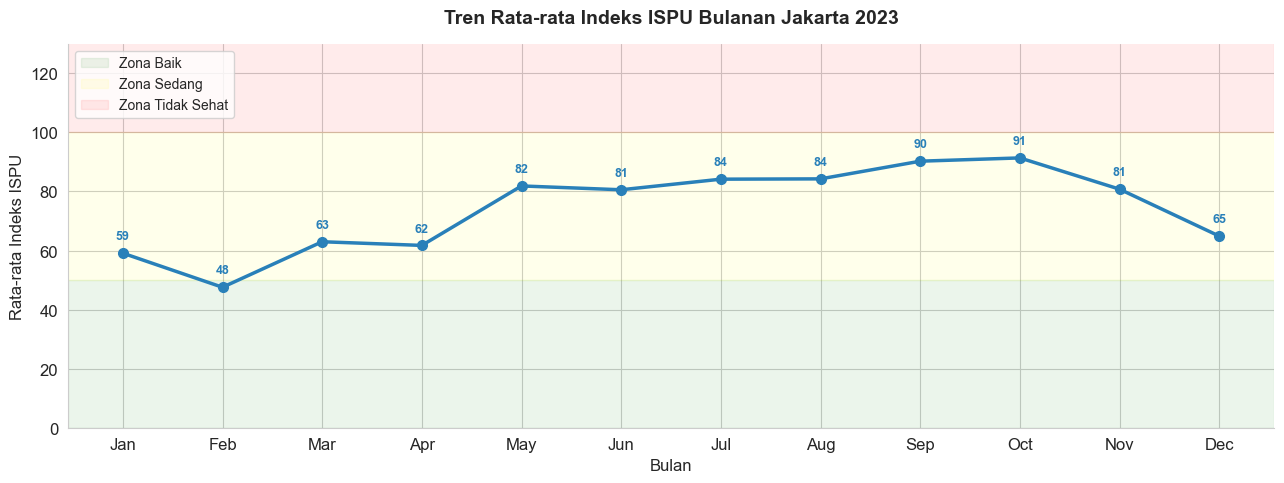

Grafik berhasil disimpan!


In [14]:
#VISUALISASI 3: TREN ISPU BULANAN

urutan_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Rata-rata indeks maksimum (max) per bulan — ini angka ISPU harian keseluruhan
tren_bulanan = df_clean.groupby('nama_bulan')['max'].mean().reindex(urutan_bulan).dropna()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(tren_bulanan.index, tren_bulanan.values,
        color='#2980b9', linewidth=2.5, marker='o', markersize=7, zorder=3)

# Warnai area berdasarkan zona bahaya
ax.axhspan(0,   50,  alpha=0.08, color='green',  label='Zona Baik')
ax.axhspan(50,  100, alpha=0.08, color='yellow', label='Zona Sedang')
ax.axhspan(100, 200, alpha=0.08, color='red',    label='Zona Tidak Sehat')

# Label nilai di setiap titik
for x, y in zip(tren_bulanan.index, tren_bulanan.values):
    ax.annotate(f'{y:.0f}', (x, y),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, color='#2980b9', fontweight='bold')

ax.set_title('Tren Rata-rata Indeks ISPU Bulanan Jakarta 2023',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Rata-rata Indeks ISPU', fontsize=12)
ax.set_ylim(0, 130)
ax.legend(loc='upper left', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/viz3_tren_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik berhasil disimpan!")

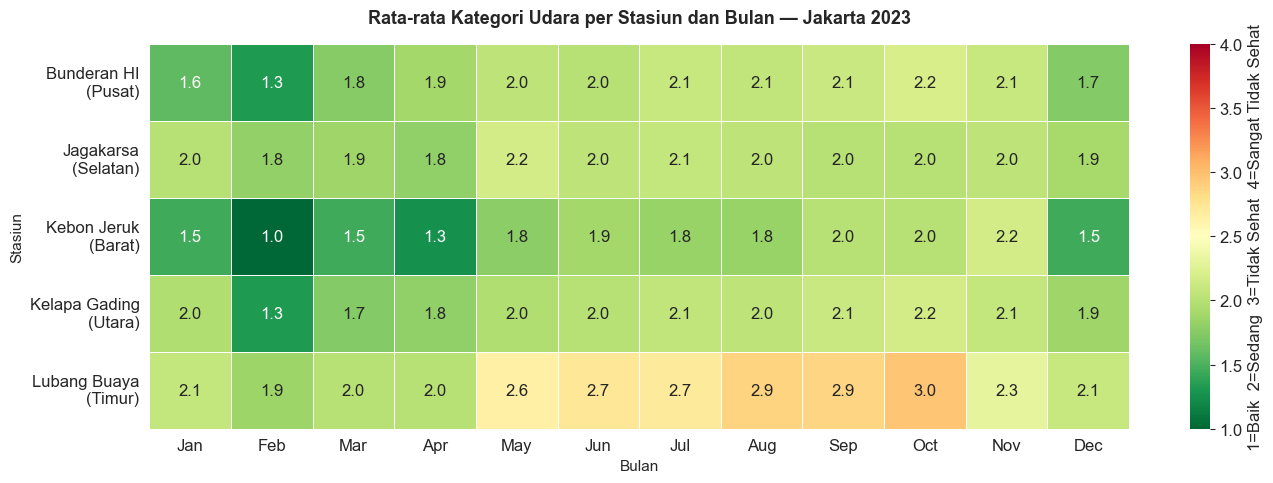

Grafik berhasil disimpan!


In [16]:
#VISUALISASI 4: HEATMAP KATEGORI UDARA PER STASIUN PER BULAN

# Mapping kategori ke angka untuk heatmap
kategori_map = {
    'BAIK': 1,
    'SEDANG': 2,
    'TIDAK SEHAT': 3,
    'SANGAT TIDAK SEHAT': 4
}

df_clean['kategori_num'] = df_clean['kategori'].map(kategori_map)

# Pivot: baris = stasiun, kolom = bulan
pivot = df_clean.groupby(['stasiun_singkat', 'nama_bulan'])['kategori_num'].mean()
pivot = pivot.unstack('nama_bulan').reindex(columns=urutan_bulan)

fig, ax = plt.subplots(figsize=(14, 5))

hm = sns.heatmap(pivot,
                 annot=True, fmt='.1f',
                 cmap='RdYlGn_r',
                 vmin=1, vmax=4,
                 linewidths=0.5,
                 ax=ax,
                 cbar_kws={'label': '1=Baik  2=Sedang  3=Tidak Sehat  4=Sangat Tidak Sehat'})

ax.set_title('Rata-rata Kategori Udara per Stasiun dan Bulan — Jakarta 2023',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Stasiun', fontsize=11)
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/viz4_heatmap_stasiun_bulan.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafik berhasil disimpan!")

In [17]:
#RINGKASAN INSIGHT

print("""
KUALITAS UDARA JAKARTA 2023 — TEMUAN UTAMA

1. Udara bersih di Jakarta lebih sering jadi pengecualian.
   Dari 1.804 hari pengukuran, hanya 13.1% yang masuk
   kategori Baik. Tiga perempat tahun sisanya berkategori
   Sedang, dan 207 hari sudah masuk zona Tidak Sehat.

2. Musim hujan adalah satu-satunya penyelamat yang konsisten.
   Februari mencatat indeks terendah (48) — satu-satunya
   bulan yang menyentuh zona Baik. Begitu kemarau tiba,
   semua stasiun kompak memburuk hingga Oktober (indeks 91).
   El Niño 2023 diduga memperpanjang periode buruk ini.

3. Lubang Buaya adalah titik paling kritis di Jakarta.
   PM2.5-nya mendekati angka 95 dan di Oktober rata-rata
   kategorinya sudah 3.0 (Tidak Sehat) — jauh melampaui
   empat stasiun lainnya yang masih di kisaran 2.0.

4. PM2.5 adalah polutan yang paling perlu diwaspadai.
   Semua stasiun melampaui batas Sedang untuk polutan ini.
   Berbahaya karena ukurannya terlalu kecil untuk disaring
   saluran pernapasan dan langsung masuk ke aliran darah.

5. Ada anomali di Jagakarsa yang perlu diselidiki lebih lanjut.
   SO2-nya relatif tinggi padahal bukan kawasan industri
   maupun pusat lalu lintas padat — menarik untuk diteliti.
""")


KUALITAS UDARA JAKARTA 2023 — TEMUAN UTAMA

1. Udara bersih di Jakarta lebih sering jadi pengecualian.
   Dari 1.804 hari pengukuran, hanya 13.1% yang masuk
   kategori Baik. Tiga perempat tahun sisanya berkategori
   Sedang, dan 207 hari sudah masuk zona Tidak Sehat.

2. Musim hujan adalah satu-satunya penyelamat yang konsisten.
   Februari mencatat indeks terendah (48) — satu-satunya
   bulan yang menyentuh zona Baik. Begitu kemarau tiba,
   semua stasiun kompak memburuk hingga Oktober (indeks 91).
   El Niño 2023 diduga memperpanjang periode buruk ini.

3. Lubang Buaya adalah titik paling kritis di Jakarta.
   PM2.5-nya mendekati angka 95 dan di Oktober rata-rata
   kategorinya sudah 3.0 (Tidak Sehat) — jauh melampaui
   empat stasiun lainnya yang masih di kisaran 2.0.

4. PM2.5 adalah polutan yang paling perlu diwaspadai.
   Semua stasiun melampaui batas Sedang untuk polutan ini.
   Berbahaya karena ukurannya terlalu kecil untuk disaring
   saluran pernapasan dan langsung masuk ke

In [19]:
#FILE README.md

readme = """# Analisis Kualitas Udara Jakarta 2023

Proyek ini menganalisis data ISPU (Indeks Standar Pencemar Udara)
dari 5 stasiun pemantauan resmi di DKI Jakarta sepanjang tahun 2023.
Data bersumber dari Jakarta Open Data (data.jakarta.go.id).

## Pertanyaan yang Ingin Dijawab

- Seberapa sering udara Jakarta berada di level aman?
- Bulan apa yang paling buruk dan paling bersih?
- Wilayah mana yang paling terdampak polusi?
- Polutan apa yang paling dominan?

## Dataset

- Sumber: [Jakarta Open Data](https://data.jakarta.go.id)
- Periode: Desember 2022 – November 2023
- Jumlah data: 1.804 baris (setelah pembersihan)
- Stasiun: Bunderan HI, Kelapa Gading, Jagakarsa, Lubang Buaya, Kebon Jeruk

## Temuan Utama

1. Hanya **13.1%** hari sepanjang 2023 yang berkategori Baik —
   udara bersih adalah pengecualian di Jakarta, bukan standar.
2. **Februari** adalah bulan terbersih (indeks 48), bertepatan
   dengan puncak musim hujan.
3. **Oktober** adalah bulan terburuk (indeks 91), diperparah
   El Niño 2023 yang memperpanjang musim kemarau.
4. **Lubang Buaya (Jakarta Timur)** adalah wilayah paling kritis —
   satu-satunya stasiun yang rata-rata kategorinya mencapai
   Tidak Sehat di bulan Oktober.
5. **PM2.5** melampaui batas Sedang di semua stasiun sepanjang tahun.

## Visualisasi

| # | Judul | Deskripsi |
|---|-------|-----------|
| 1 | Distribusi Kategori Udara | Proporsi hari per kategori sepanjang 2023 |
| 2 | Rata-rata Polutan per Stasiun | Perbandingan 6 polutan antar 5 wilayah |
| 3 | Tren ISPU Bulanan | Pola musiman indeks udara sepanjang tahun |
| 4 | Heatmap Stasiun vs Bulan | Peta panas kategori udara per lokasi per bulan |

## Tools yang Digunakan

- Python 3.11
- pandas, numpy — pengolahan data
- matplotlib, seaborn — visualisasi
- Jupyter Notebook (VS Code)

## Cara Menjalankan

```bash
pip install pandas numpy matplotlib seaborn
```

Buka file `notebooks/analisis.ipynb` dan jalankan sel dari atas ke bawah.

## Struktur Folder
01-kualitas-udara-jakarta/
├── data/
│   ├── raw/
│   │   └── ispu_jakarta_2023.xls
│   ├── viz1_kategori_udara.png
│   ├── viz2_polutan_per_stasiun.png
│   ├── viz3_tren_bulanan.png
│   └── viz4_heatmap_stasiun_bulan.png
└── notebooks/
└── analisis.ipynb
"""

with open('../README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("README.md berhasil dibuat!")

README.md berhasil dibuat!
